COMPAS (Correctional Offender Management Profiling for Alternative Sanctions)

In [1]:
import pandas as pd
import numpy as np

In [2]:
compas_df = pd.read_csv('compas-scores-two-years.csv')

In [3]:
compas_df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [15]:
compas_df[['decile_score', 'v_score_text']]

,decile_score,v_score_text
0,1,Low
1,3,Low
2,4,Low
3,8,Medium
4,1,Low
...,...,...
7209,7,Medium
7210,3,Medium
7211,1,Low
7212,2,Low


In [9]:
compas_df['decile_score'].value_counts(normalize=True).round(2)

,proportion
decile_score,
1,0.20
2,0.13
4,0.11
3,0.10
5,0.09
6,0.09
7,0.08
8,0.07
9,0.07


In [22]:
compas_df['race'].value_counts(normalize=True).round(3)*100

,proportion
race,
African-American,51.2
Caucasian,34.0
Hispanic,8.8
Other,5.2
Asian,0.4
Native American,0.2


In [27]:
compas_df['race'].value_counts()

,count
race,
African-American,3696
Caucasian,2454
Hispanic,637
Other,377
Asian,32
Native American,18


<Axes: title={'center': 'Decile Score Histogram by Race'}, xlabel='race', ylabel='% with Decile Score'>

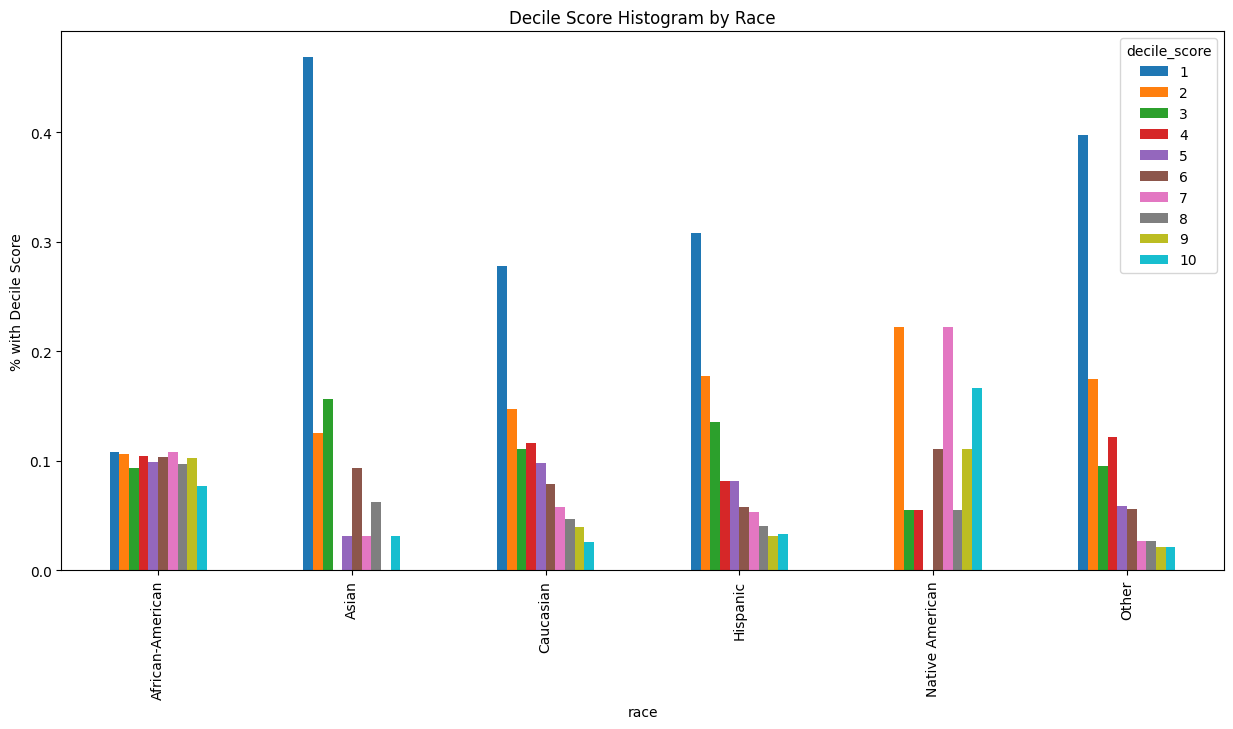

In [5]:
compas_df.groupby('race')['decile_score'].value_counts(
    normalize=True
).unstack().plot(
    kind='bar', figsize=(15, 7),
    title='Decile Score Histogram by Race', ylabel='% with Decile Score'
)

**알고리즘의 예측 결과 (Prediction / Risk Assessment)**

> decile_score: COMPAS 알고리즘이 피의자의 특성을 바탕으로 계산해 낸 위험도 예측 점수(1~10점)

> is_med_or_high_risk: 법원 기준대로 점수가 5점 이상이면 위험군(True), 아니면 저위험군(False)으로 예측 결과를 이진화(Binary)한 값

**실제 결과 (Ground Truth / Actual Outcome)**

> two_year_recid: 해당 피의자가 석방된 후 2년 이내에 실제로 다시 범죄를 저질렀는지(1) 안 저질렀는지(0) 추적 조사하여 기록한 실제 사실 데이터

In [23]:
# Courts generally use  a decile score of 5 to label someone as being medium risk.
compas_df['is_med_or_high_risk'] = (compas_df['decile_score']>=5).astype(bool)


In [24]:
# Hmm, not great if the court's system of 5 or higher on the decile score is only accurate 65% of the time
(compas_df['is_med_or_high_risk']==compas_df['two_year_recid']).mean()


np.float64(0.6537288605489326)

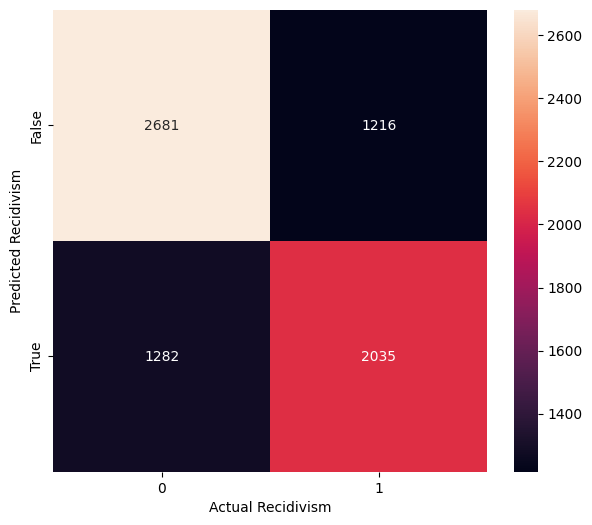

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# heatmap of recidivism
cm = pd.crosstab(
    compas_df['is_med_or_high_risk'], compas_df['two_year_recid'],
    rownames=['Predicted Recidivism'], colnames=['Actual Recidivism']
)
p = plt.figure(figsize=(7,6))
p = sns.heatmap(cm, annot=True, fmt='d')

<Axes: title={'center': 'Recidivism vs Decile Score'}, xlabel='Decile Score', ylabel='Recidivism Rate'>

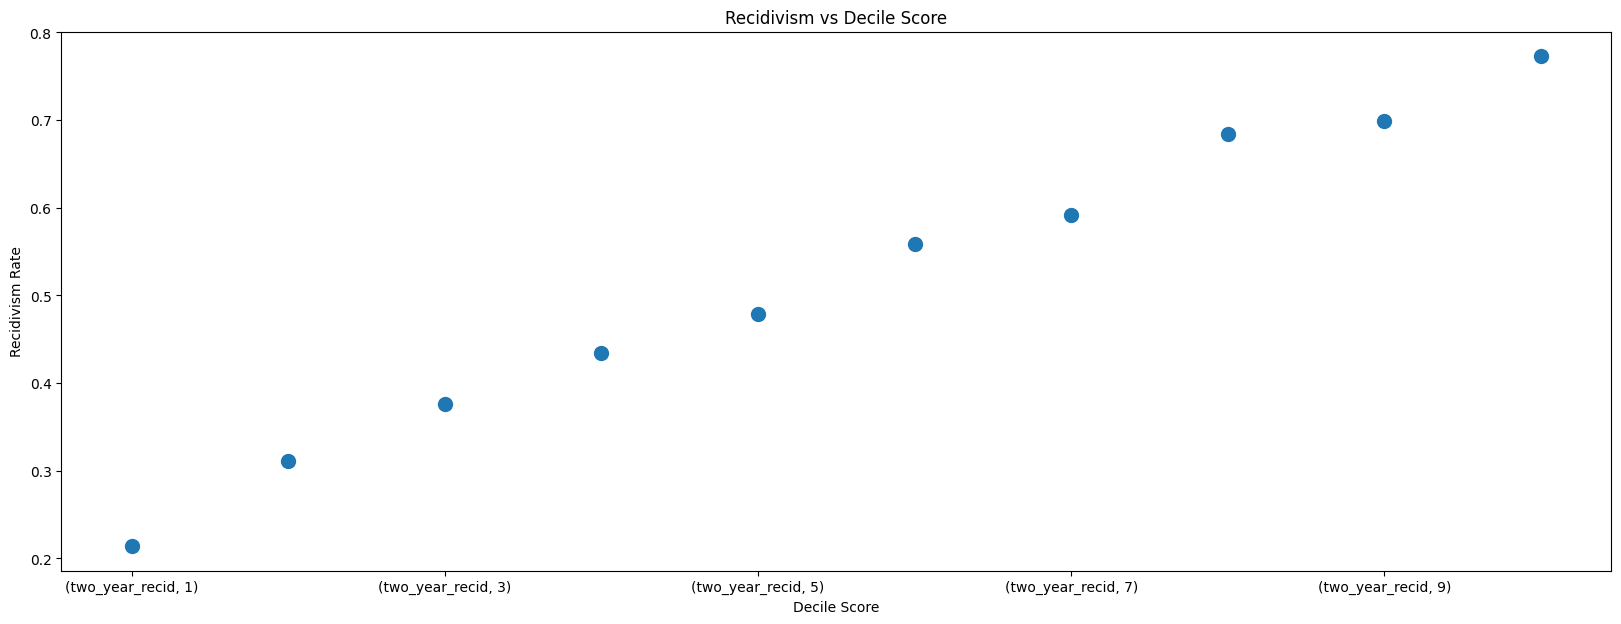

In [26]:
# scatter plot
compas_df.groupby('decile_score')[['two_year_recid']].mean().unstack().T.plot(
    xlabel='Decile Score', ylabel='Recidivism Rate', title='Recidivism vs Decile Score',
    style='.', figsize=(20, 7),
    ms=20
)

In [28]:
# scatter plot
compas_df.groupby(
    ['race', 'decile_score']
)[['two_year_recid']].mean().unstack()

two_year_recid                                          \
decile_score                 1         2         3         4         5    
race                                                                      
African-American       0.228643  0.302799  0.419075  0.459740  0.482192   
Asian                  0.066667  0.000000  0.400000       NaN  1.000000   
Caucasian              0.208517  0.313019  0.340659  0.396491  0.460581   
Hispanic               0.244898  0.318584  0.313953  0.346154  0.538462   
Native American             NaN  0.000000  0.000000  1.000000       NaN   
Other                  0.173333  0.378788  0.388889  0.543478  0.454545   

                                                                    
decile_score            6         7         8         9         10  
race                                                                
African-American  0.559896  0.592500  0.682451  0.707895  0.793706  
Asian             0.666667  1.000000  0.500000       NaN  1.000000  
Caucasian         0.572165  0.615385  0.719298  0.693878  0.703125  
Hispanic          0.567568  0.470588  0.500000  0.550000  0.666667  
Native American   0.500000  0.750000  1.000000  0.500000  1.000000  
Other             0.380952  0.500000  0.800000  0.750000  0.750000

<Axes: title={'center': 'Recidivism vs Decile Score by Race'}, xlabel='Decile Score', ylabel='Recidivism Rate'>

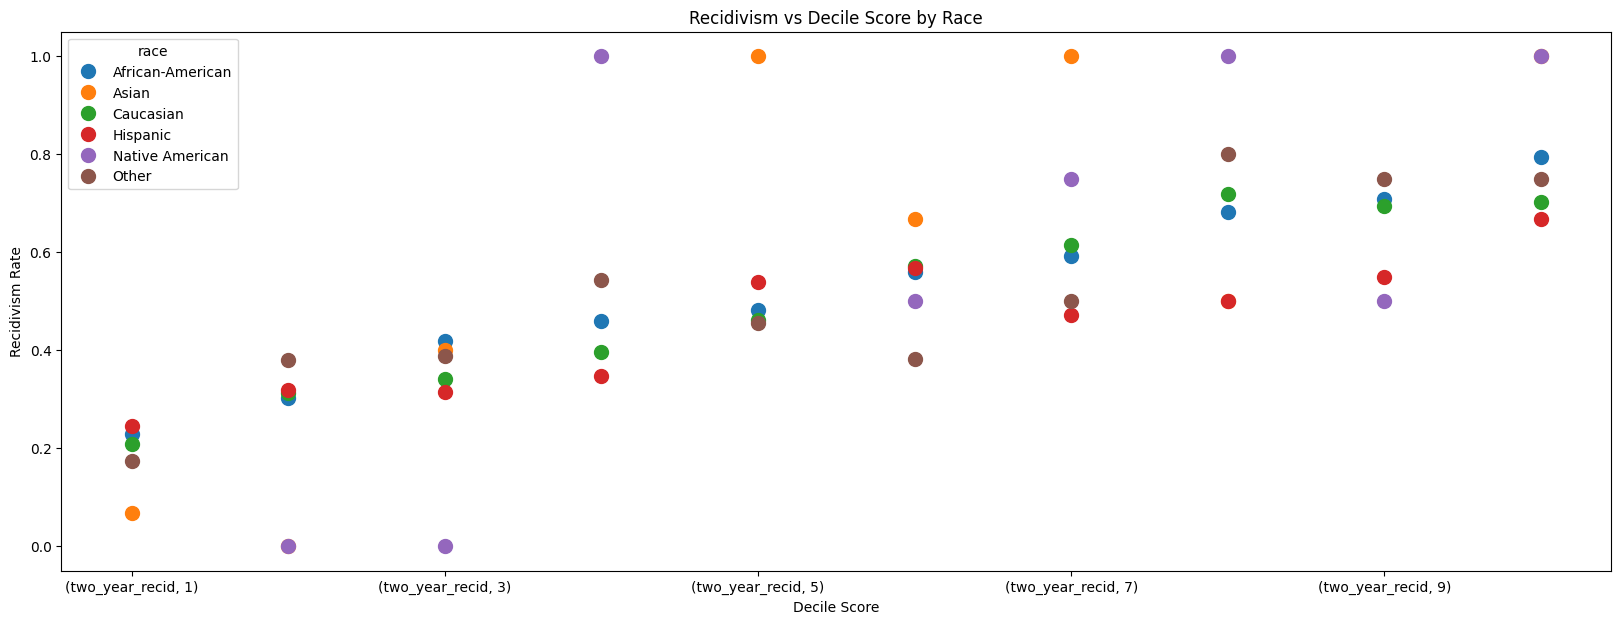

In [29]:
# scatter plot
compas_df.groupby(
    ['race', 'decile_score']
)[['two_year_recid']].mean().unstack().T.plot(
    xlabel='Decile Score', ylabel='Recidivism Rate', title='Recidivism vs Decile Score by Race',
    style='.', figsize=(20, 7),
    ms=20
)

In [30]:
compas_df = compas_df[["sex", "age", "race", "juv_fel_count", "juv_misd_count",
                 "juv_other_count", "priors_count", "c_charge_degree", "two_year_recid"]]
compas_df.head()

,sex,age,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid
0,Male,69,Other,0,0,0,0,F,0
1,Male,34,African-American,0,0,0,0,F,1
2,Male,24,African-American,0,0,1,4,F,1
3,Male,23,African-American,0,1,0,1,F,0
4,Male,43,Other,0,0,0,2,F,0


In [31]:
compas_df['race'].value_counts(normalize=True)

,proportion
race,
African-American,0.512337
Caucasian,0.340172
Hispanic,0.088301
Other,0.052259
Asian,0.004436
Native American,0.002495


In [32]:
compas_df.groupby('race')['two_year_recid'].describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,3696.0,0.514340,0.499862,0.0,0.0,1.0,1.0,1.0
Asian,32.0,0.281250,0.456803,0.0,0.0,0.0,1.0,1.0
Caucasian,2454.0,0.393643,0.488657,0.0,0.0,0.0,1.0,1.0
Hispanic,637.0,0.364207,0.481585,0.0,0.0,0.0,1.0,1.0
Native American,18.0,0.555556,0.511310,0.0,0.0,1.0,1.0,1.0
Other,377.0,0.352785,0.478472,0.0,0.0,0.0,1.0,1.0


In [33]:
# re-label two races as Other.
# This is done purely for educational reasons and to avoid addressing issues with a skewed sample in our data
compas_df.loc[compas_df['race'].isin(['Native American', 'Asian']), 'race'] = 'Other'

In [34]:
compas_df.groupby('race')['two_year_recid'].describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,3696.0,0.514340,0.499862,0.0,0.0,1.0,1.0,1.0
Caucasian,2454.0,0.393643,0.488657,0.0,0.0,0.0,1.0,1.0
Hispanic,637.0,0.364207,0.481585,0.0,0.0,0.0,1.0,1.0
Other,427.0,0.355972,0.479368,0.0,0.0,0.0,1.0,1.0


<Axes: title={'center': 'Actual Recidivism Rates by Race'}, xlabel='race'>

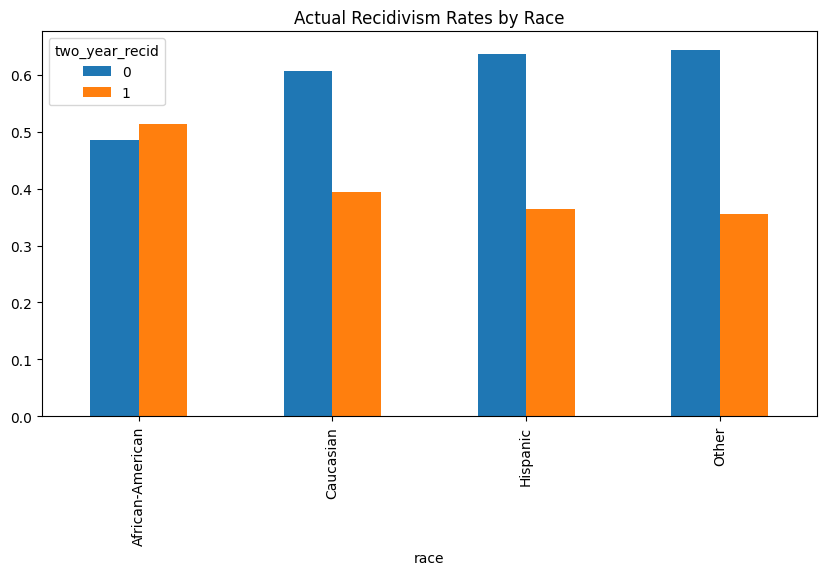

In [35]:
compas_df.groupby('race')['two_year_recid'].value_counts(
    normalize=True
).unstack().plot(
    kind='bar', figsize=(10, 5), title='Actual Recidivism Rates by Race'
)

<Axes: title={'center': '% of Charge Degree'}, xlabel='Charge Degree', ylabel='%'>

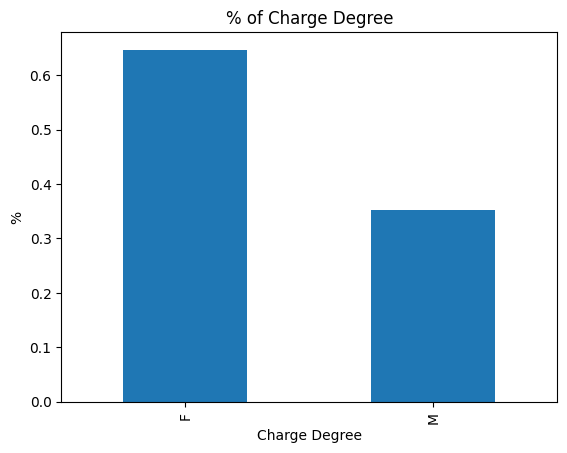

In [36]:
compas_df['c_charge_degree'].value_counts(normalize=True).plot(
    kind='bar', title='% of Charge Degree', ylabel='%', xlabel='Charge Degree'
)

<Axes: title={'center': 'Histogram of Age'}, xlabel='Age', ylabel='Frequency'>

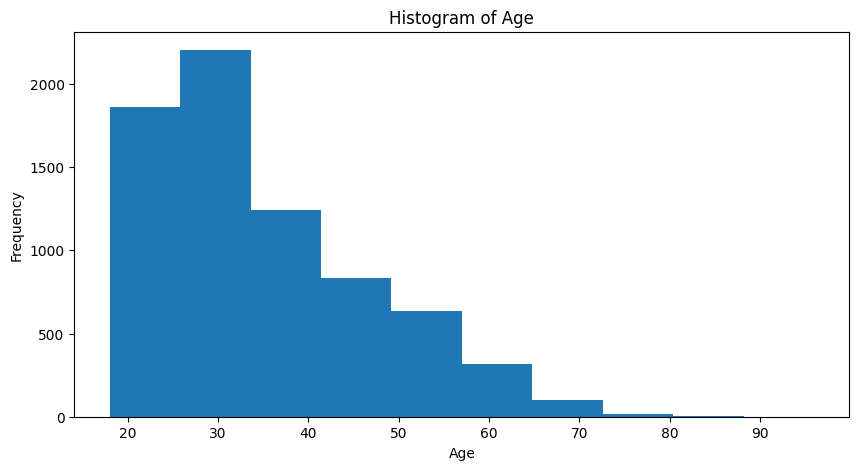

In [37]:
# Right skew on Age
compas_df['age'].plot(
    title='Histogram of Age', kind='hist', xlabel='Age', figsize=(10, 5)
)

<Axes: title={'center': 'Histogram of Priors Count'}, xlabel='Priors', ylabel='Frequency'>

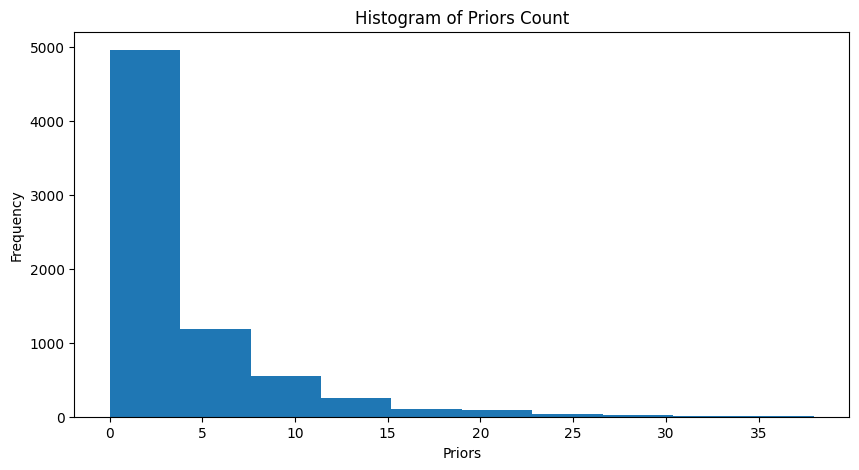

In [38]:
# Right skew on Priors as well
compas_df['priors_count'].plot(
    title='Histogram of Priors Count', kind='hist', xlabel='Priors', figsize=(10, 5)
)

In [39]:
compas_df[["juv_fel_count", "juv_misd_count", "juv_other_count"]].describe()

,juv_fel_count,juv_misd_count,juv_other_count
count,7214.000000,7214.000000,7214.000000
mean,0.067230,0.090934,0.109371
std,0.473972,0.485239,0.501586
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,20.000000,13.000000,17.000000


In [40]:
# feature construction, add up our three juv columns and remove the original features
compas_df['juv_count'] = compas_df[["juv_fel_count", "juv_misd_count", "juv_other_count"]].sum(axis=1)

compas_df[['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'juv_count']].describe()

,juv_fel_count,juv_misd_count,juv_other_count,juv_count
count,7214.000000,7214.000000,7214.000000,7214.000000
mean,0.067230,0.090934,0.109371,0.267535
std,0.473972,0.485239,0.501586,0.952763
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,20.000000,13.000000,17.000000,21.000000


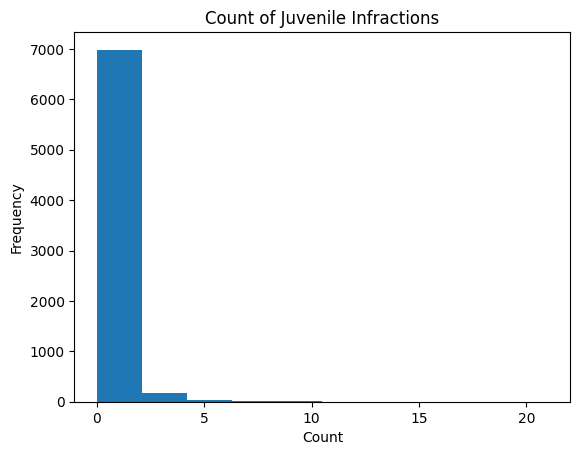

In [41]:
compas_df['juv_count'].plot(
    title='Count of Juvenile Infractions', kind='hist', xlabel='Count'
)

name = 'juv_count'
plt.savefig(f'{name}.svg', dpi=500)
plt.savefig(f'{name}.png', dpi=500)

In [42]:
compas_df['juv_count'].mean(), compas_df['juv_count'].std()

(np.float64(0.2675353479345717), 0.9527632275173195)

In [43]:
compas_df = compas_df.drop(["juv_fel_count", "juv_misd_count", "juv_other_count"], axis=1)

In [44]:
compas_df.head()

,sex,age,race,priors_count,c_charge_degree,two_year_recid,juv_count
0,Male,69,Other,0,F,0,0
1,Male,34,African-American,0,F,1,0
2,Male,24,African-American,4,F,1,1
3,Male,23,African-American,1,F,0,1
4,Male,43,Other,2,F,0,0


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split up our data
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(compas_df.drop('two_year_recid', axis=1),
                                                    compas_df['two_year_recid'],
                                                    compas_df['race'],
                                                    stratify=compas_df['two_year_recid'],
                                                    test_size=0.3,
                                                    random_state=0)

# our static classifier
classifier = RandomForestClassifier(max_depth=10, n_estimators=20, random_state=0)

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import OneHotEncoder, StandardScaler


categorical_features = ['race', 'sex', 'c_charge_degree']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='if_binary'))
])

numerical_features = ["age", "priors_count"]
numerical_transformer = Pipeline(steps=[
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
])

clf_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])


clf_tree.fit(X_train, y_train)

unaware_y_preds = clf_tree.predict(X_test)

In [47]:
preprocessor.fit_transform(X_train).shape

(5049, 8)

In [50]:
!pip install dalex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
Preparation of a new explainer is initiated

  -> data              : 2165 rows 6 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2165 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest Bias Unaware
  -> predict function  : <function yhat_proba_default at 0x7c97d50bfd80> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.0, mean = 0.444, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference 

In [52]:
import dalex as dx

exp_tree = dx.Explainer(clf_tree, X_test, y_test, label='Random Forest Bias Unaware', verbose=True)

Preparation of a new explainer is initiated

  -> data              : 2165 rows 6 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2165 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest Bias Unaware
  -> predict function  : <function yhat_proba_default at 0x7c97d50bfd80> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.0, mean = 0.444, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.986, mean = 0.00662, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


In [51]:
exp_tree.model_performance()

,recall,precision,f1,accuracy,auc
Random Forest Bias Unaware,0.560451,0.628736,0.592633,0.652656,0.69393


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=unaware_y_preds))

              precision    recall  f1-score   support

           0       0.67      0.73      0.70      1189
           1       0.63      0.56      0.59       976

    accuracy                           0.65      2165
   macro avg       0.65      0.64      0.65      2165
weighted avg       0.65      0.65      0.65      2165



In [54]:
exp_tree.model_parts().plot()

<!doctype html>

In [55]:
# Recidivism by race in our test set
y_test.groupby(race_test).mean()

,two_year_recid
race,
African-American,0.514652
Caucasian,0.407162
Hispanic,0.327778
Other,0.345324


In [56]:
# Predicted Recidivism by race in our bias-unaware model
pd.Series(unaware_y_preds, index=y_test.index).groupby(race_test).mean()

,0
race,
African-American,0.508242
Caucasian,0.285146
Hispanic,0.255556
Other,0.381295


In [57]:
mf_tree = exp_tree.model_fairness(protected=race_test, privileged = "Caucasian")

# TPR(r) = TP / AP                           ( aka sensitivity )
# TNR(r) = TN / AN                           ( aka specificity )
# PPV(r) = TP / (PP)                         ( aka precision )
# NPV(r) = TN / (PN)
# FNR(r) = FN / AP  OR 1 - TPR
# FPR(r) = FP / AN  OR 1 - TNR
# FDR(r) = FP / (PP) OR 1 - PPV
# FOR(r) = FN / (PN) OR 1 - NPV
# ACC(r) = TP + TN  / (TP + TN + FP + FN)    ( Overall accuracy by Race)
# STP(r) = TP + FP / (TP + FP + FP + FN)     ( aka P[recidivism predicted | Race=r] )

mf_tree.metric_scores

,TPR,TNR,PPV,NPV,FNR,FPR,FDR,FOR,ACC,STP
African-American,0.665,0.658,0.674,0.650,0.335,0.342,0.326,0.350,0.662,0.508
Caucasian,0.407,0.799,0.581,0.662,0.593,0.201,0.419,0.338,0.639,0.285
Hispanic,0.356,0.785,0.447,0.714,0.644,0.215,0.553,0.286,0.644,0.261
Other,0.562,0.714,0.509,0.756,0.438,0.286,0.491,0.244,0.662,0.381


In [58]:
# Each value is the value from the metric_scores table divided by the Causcaian value

mf_tree.fairness_check()

Bias detected in 4 metrics: TPR, PPV, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Caucasian'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
                       TPR       ACC       PPV       FPR       STP
African-American  1.633907  1.035994  1.160069  1.701493  1.782456
Hispanic          0.874693  1.007825  0.769363  1.069652  0.915789
Other             1.380835  1.035994  0.876076  1.422886  1.336842


In [59]:
# Caucasian is our privilaged race

# Equal Opportunity Ratio(r)   = TPR(r) / TPR(Caucasian) == TPR from dalex's fairness_check
# Predictive Parity Ratio(r)   = PPV(r) / PPV(Caucasian) == PPV from dalex's fairness_check
# Predictive Equality Ratio(r) = FPR(r) / FPR(Caucasian) == FPR from dalex's fairness_check
# Accuracy Equality Ratio(r)   = ACC(r) / ACC(Caucasian) == ACC from dalex's fairness_check
# Statistical Parity Ratio(r)  = STP(r) / STP(Caucasian) == STP from dalex's fairness_check

In [60]:
mf_tree.plot()  # Same numbers from the fairness_check in a plot

/usr/local/lib/python3.13/dist-packages/dalex/fairness/_group_fairness/utils.py:209: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(dropna=False)


<!doctype html>

In [61]:
# EG STP Parity Loss:

# STP metrics for unprivileged groups
unpriv_stp = [0.508, 0.261, 0.381]

# STP metrics for privileged group
caucasian_stp = 0.285

# 0.956 appears as light orange in the following figure
sum([abs(np.log(u / caucasian_stp)) for u in unpriv_stp])

np.float64(0.956271235113839)

In [62]:
# Plot of parity loss of each metric
mf_tree.plot(type = 'stacked')

<!doctype html>

In [63]:
def show_proportions(sensitive_features, y_pred, y=None, description=None):
    print(f'\n{description}\n')
    indices = {}
    positive_indices = {}
    negative_indices = {}
    groups = np.unique(sensitive_features.values)
    n_groups = len(groups)
    max_group_length = max([len(group) for group in groups])
    for index, group in enumerate(groups):
        indices[group] = sensitive_features.index[sensitive_features == group]
        group_recidivism_pct = round(sum(y_pred[indices[group]]) / len(indices[group]), 5)
        buffer = " " * (max_group_length - len(group))
        print(f'P(recidivism | {group})                {buffer}= {group_recidivism_pct}')

        if y is not None:
            positive_indices[group] = sensitive_features.index[
                (sensitive_features == group) & (y == True)
            ]
            negative_indices[group] = sensitive_features.index[
                (sensitive_features == group) & (y == False)
            ]
            prob_1 = round(sum(y_pred[positive_indices[group]]) / len(positive_indices[group]), 5)
            prob_0 = round(sum(y_pred[negative_indices[group]]) / len(negative_indices[group]), 5)

            print(f'P(recidivism | {group}, recidivism)    {buffer}= {prob_1}')
            print(f'P(recidivism | {group}, no recidivism) {buffer}= {prob_0}')

In [64]:
show_proportions(
    race_test,
    y_test,
    description="original test data:"
)
show_proportions(
    race_test,
    pd.Series(unaware_y_preds, index=y_test.index),
    y=y_test,
    description="fairness-unaware prediction on test data:"
)
plt.show()


original test data:

P(recidivism | African-American)                = 0.51465
P(recidivism | Caucasian)                       = 0.40716
P(recidivism | Hispanic)                        = 0.32778
P(recidivism | Other)                           = 0.34532

fairness-unaware prediction on test data:

P(recidivism | African-American)                = 0.50824
P(recidivism | African-American, recidivism)    = 0.66548
P(recidivism | African-American, no recidivism) = 0.34151
P(recidivism | Caucasian)                       = 0.28515
P(recidivism | Caucasian, recidivism)           = 0.40717
P(recidivism | Caucasian, no recidivism)        = 0.20134
P(recidivism | Hispanic)                        = 0.25556
P(recidivism | Hispanic, recidivism)            = 0.35593
P(recidivism | Hispanic, no recidivism)         = 0.20661
P(recidivism | Other)                           = 0.38129
P(recidivism | Other, recidivism)               = 0.5625
P(recidivism | Other, no recidivism)            = 0.28571


In [65]:
# Correlating factors to race

In [67]:
import numpy as np

compas_df.select_dtypes(include=np.number).corrwith(compas_df['race'] == 'African-American').sort_values()

,0
age,-0.179095
juv_count,0.111835
two_year_recid,0.131200
priors_count,0.202897


,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,3696.0,4.438853,5.579835,0.0,1.0,2.0,6.0,38.0
Caucasian,2454.0,2.586797,3.798803,0.0,0.0,1.0,3.0,36.0
Hispanic,637.0,2.252747,3.647673,0.0,0.0,1.0,2.0,26.0
Other,427.0,2.016393,3.695856,0.0,0.0,1.0,2.5,31.0


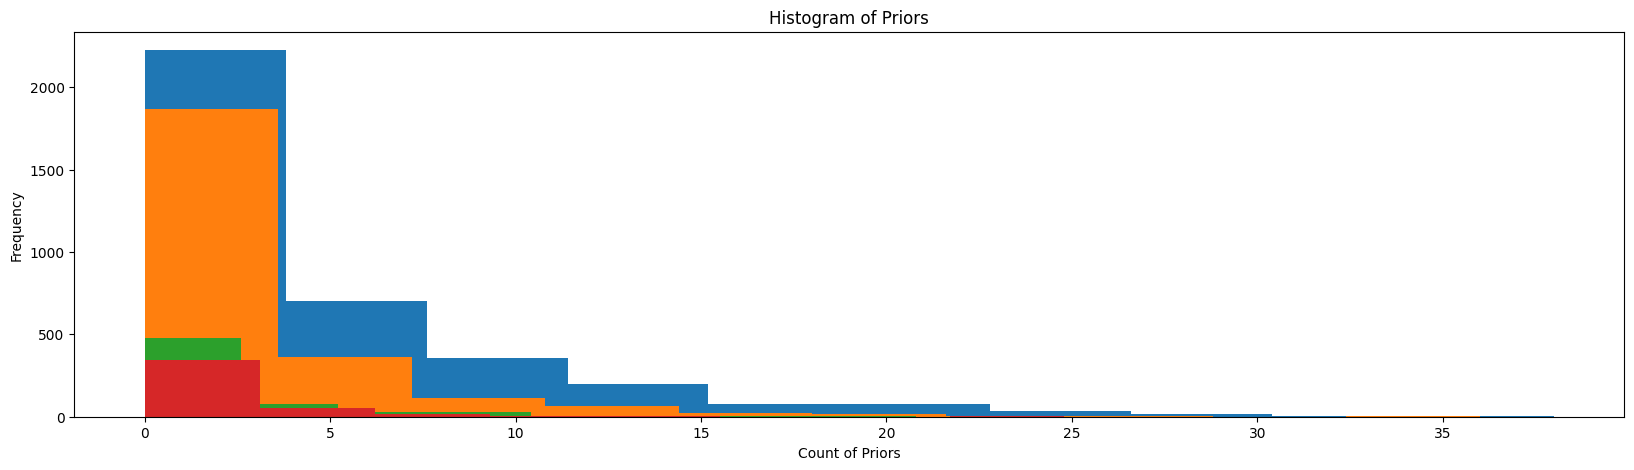

In [68]:
# Priors is extremely skewed by looking at the differences in mean/median/std across the racial categories
compas_df.groupby('race')['priors_count'].plot(
    figsize=(20,5),
    kind='hist', xlabel='Count of Priors', title='Histogram of Priors'
)
compas_df.groupby('race')['priors_count'].describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,3696.0,32.740801,10.858391,18.0,25.0,30.0,38.00,77.0
Caucasian,2454.0,37.726569,12.761373,18.0,27.0,35.0,47.75,83.0
Hispanic,637.0,35.455259,11.877783,19.0,26.0,33.0,43.00,96.0
Other,427.0,35.131148,11.634159,19.0,25.0,33.0,43.00,76.0


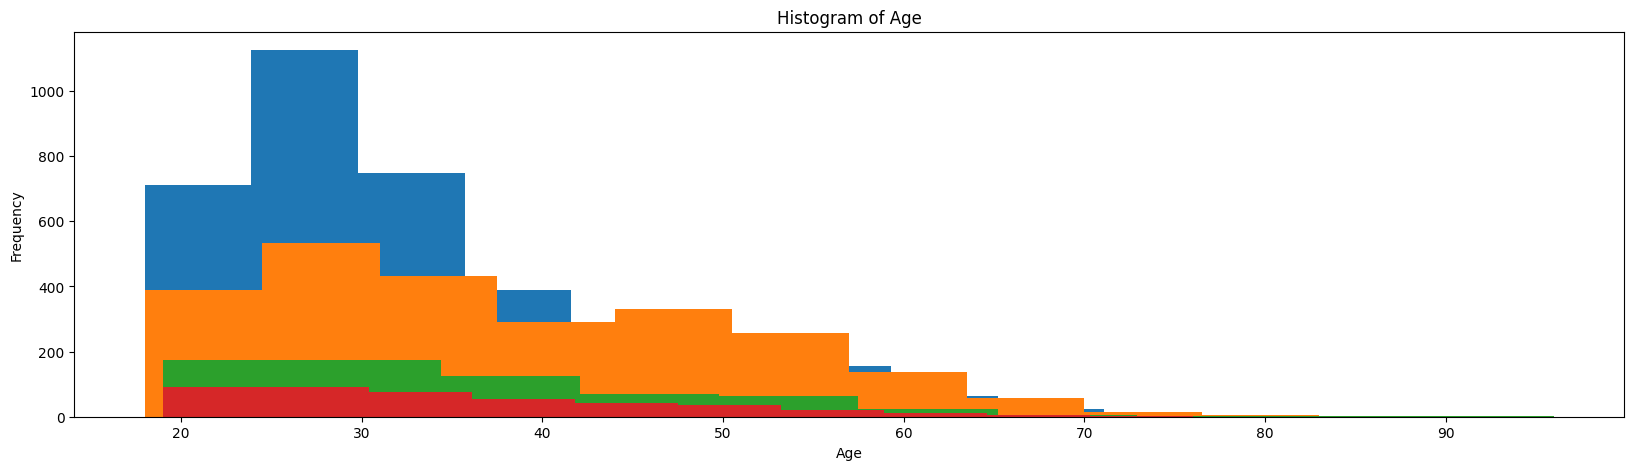

In [69]:
# Age is not very skewed
compas_df.groupby('race')['age'].plot(
    figsize=(20,5),
    kind='hist', xlabel='Age', title='Histogram of Age'
)
compas_df.groupby('race')['age'].describe()

In [70]:
# https://towardsdatascience.com/ai-fairness-explanation-of-disparate-impact-remover-ce0da59451f1

In [71]:
from sklearn.preprocessing import PowerTransformer
from sklearn.base import BaseEstimator, TransformerMixin

class NormalizeColumnByLabel(BaseEstimator, TransformerMixin):
    def __init__(self, col, label):
        self.col = col
        self.label = label
        self.transformers = {}

    def fit(self, X, y=None):
        for group in X[self.label].unique():
            self.transformers[group] = PowerTransformer(
                method='yeo-johnson', standardize=True
            )
            self.transformers[group].fit(
                X.loc[X[self.label]==group][self.col].values.reshape(-1, 1)
            )
        return self

    def transform(self, X, y=None):
        C = X.copy()
        for group in X[self.label].unique():
            C.loc[X[self.label]==group, self.col] = self.transformers[group].transform(
                X.loc[X[self.label]==group][self.col].values.reshape(-1, 1)
            )
        return C

/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.19091358 -1.19091358  1.26869417 ... -0.10439575  0.41212247
  0.73386571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  C.loc[X[self.label]==group, self.col] = self.transformers[group].transform(


,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
African-American,2604.0,-8.868141e-17,1.000192,-1.394037,-0.549932,-0.092417,0.784661,2.276224
Caucasian,1700.0,1.097162e-16,1.000294,-1.190914,-1.190914,-0.104396,0.733866,2.293665
Hispanic,457.0,-9.911838e-17,1.001096,-1.124116,-1.124116,0.098333,0.620238,2.060623
Other,288.0,1.572816e-16,1.001741,-0.921525,-0.921525,-0.921525,0.878567,1.871600


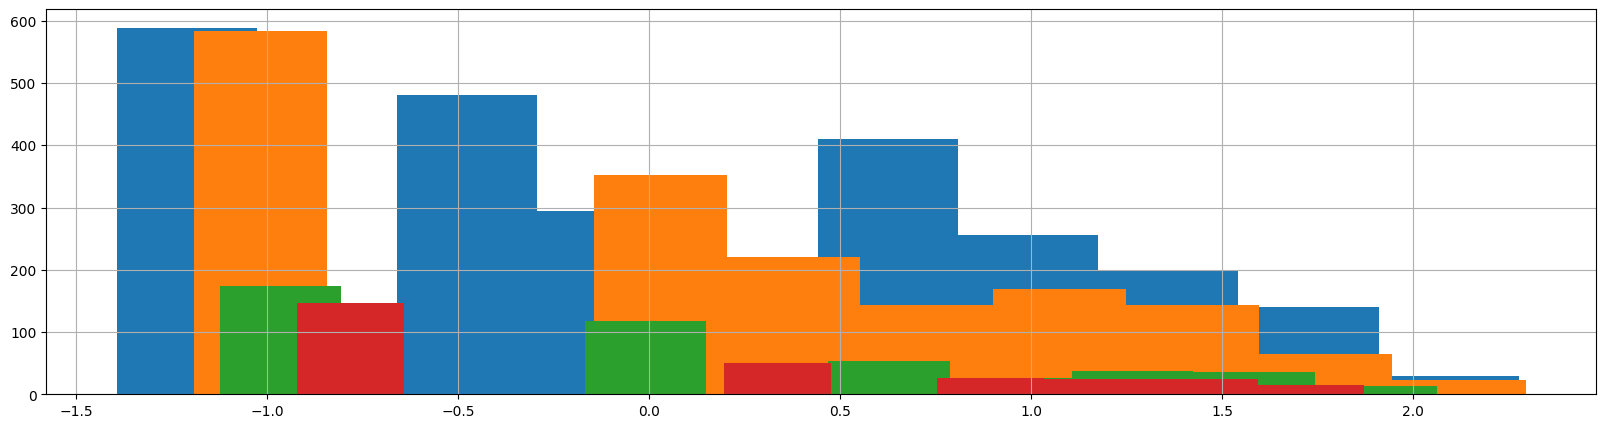

In [72]:
n = NormalizeColumnByLabel(col='priors_count', label='race')

X_train_normalized = n.fit_transform(X_train, y_train)

X_train_normalized.groupby('race')['priors_count'].hist(figsize=(20,5))
X_train_normalized.groupby('race')['priors_count'].describe()

In [73]:
clf_tree_aware = Pipeline(steps=[
    ('normalize_priors', NormalizeColumnByLabel(col='priors_count', label='race')),
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

clf_tree_aware.fit(X_train, y_train)

aware_y_preds = clf_tree_aware.predict(X_test)

/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.19091358 -1.19091358  1.26869417 ... -0.10439575  0.41212247
  0.73386571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  C.loc[X[self.label]==group, self.col] = self.transformers[group].transform(
/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.62023814  1.97137986  0.92428519  1.95253475 -1.12411644 -1.12411644
  0.62023814  1.72059699 -1.12411644  0.09833278 -1.12411644 -1.12411644
  0.09833278  0.62023814  0.92428519  1.72059699 -1.12411644  0.09833278
 -1.12411644 -1.12411644  0.09833278  1.12830757  0.62023814  0.62023814
 -1.12411644  0.92428519  0.09833278 -1.12411644  1.62019152  0.09833278
  0.09833278  0.92428519 -1.12411644  0.92428519 -1.124116

In [74]:
print(classification_report(y_true=y_test, y_pred=aware_y_preds))

              precision    recall  f1-score   support

           0       0.67      0.73      0.70      1189
           1       0.63      0.56      0.59       976

    accuracy                           0.66      2165
   macro avg       0.65      0.65      0.65      2165
weighted avg       0.65      0.66      0.65      2165



In [75]:
exp_tree_aware = dx.Explainer(clf_tree_aware, X_test, y_test, label='Random Forest DIR', verbose=False)
mf_tree_aware = exp_tree_aware.model_fairness(protected=race_test, privileged = "Caucasian")

# performance is virtually unchanged overall
pd.concat([exp.model_performance().result for exp in [exp_tree, exp_tree_aware]])

/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.62023814  1.97137986  0.92428519  1.95253475 -1.12411644 -1.12411644
  0.62023814  1.72059699 -1.12411644  0.09833278 -1.12411644 -1.12411644
  0.09833278  0.62023814  0.92428519  1.72059699 -1.12411644  0.09833278
 -1.12411644 -1.12411644  0.09833278  1.12830757  0.62023814  0.62023814
 -1.12411644  0.92428519  0.09833278 -1.12411644  1.62019152  0.09833278
  0.09833278  0.92428519 -1.12411644  0.92428519 -1.12411644 -1.12411644
  1.97137986 -1.12411644  0.09833278  0.09833278  0.62023814 -1.12411644
  0.09833278 -1.12411644 -1.12411644  0.62023814  1.62019152 -1.12411644
  0.92428519 -1.12411644  1.76150988 -1.12411644 -1.12411644  1.72059699
  1.48234303  0.62023814  0.62023814  0.62023814 -1.12411644  0.92428519
  0.09833278  1.48234303  0.09833278  1.76150988  0.09833278  1.2769125
  0.09833278 -1.12411644  0.6202

,recall,precision,f1,accuracy,auc
Random Forest Bias Unaware,0.560451,0.628736,0.592633,0.652656,0.693930
Random Forest DIR,0.560451,0.633835,0.594889,0.655889,0.694199


In [76]:
# Still using the same features, note that race has become less important.
exp_tree.model_parts().plot(objects=[exp_tree_aware.model_parts()])

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  0.21697549 -0.5499318   0.21697549 -1.39403694 -0.09241682 -1.39403694
 -0.5499318  -1.39403694  0.21697549  1.02564224 -0.09241682  0.63264833
 -0.09241682 -1.39403694 -1.39403694  1.12420399 -0.5499318   0.44861945
 -0.5499318   0.21697549  0.63264833 -0.5499318  -0.5499318  -0.5499318
  1.54679146 -1.39403694  1.02564224 -0.5499318  -1.39403694  0.78466116
  1.12420399 -1.39403694 -1.39403694 -1.39403694  0.21697549  0.63264833
 -1.39403694  0.21697549 -1.39403694 -0.5499318   1.12420399  0.21697549
  1.59932607  0.91374509 -1.39403694 -1.39403694 -0.5499318   0.44861945
  0.21697549  1.77903022 -1.39403694 -1.39403694  1.29140247 -0.5499318
 -1.39403694  0.21697549  1.8178916   0.21697549 -1.39403694  0.44861945
  1.02564224 -1.39403694  0.44861945 -0.5499318  -1.39403694 -0.5499318
  1.59932607 -0.5499318   1.21213451  1.36348393  1.9234004   0.78466116
 -1.39403694 -1.39403694  1.88991009  1.64845502 -0.09241682 -0.5499318
 -1.39403694  0.448

<!doctype html>

In [77]:
# We can see a small drop in parity loss
mf_tree.plot(objects=[mf_tree_aware], type='stacked')

<!doctype html>

In [78]:
mf_tree_aware.fairness_check()

Bias detected in 3 metrics: TPR, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Caucasian'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
                       TPR       ACC       PPV       FPR       STP
African-American  1.680798  1.035881  1.148464  1.779487  1.849462
Hispanic          0.930175  1.048362  0.853242  0.933333  0.874552
Other             1.194514  1.021841  0.853242  1.297436  1.186380


In [79]:
show_proportions(
    race_test,
    y_test,
    description="original test data:"
)
show_proportions(
    race_test,
    pd.Series(unaware_y_preds, index=y_test.index),
    y=y_test,
    description="fairness-unaware prediction on test data:"
)
show_proportions(
    race_test,
    pd.Series(aware_y_preds, index=y_test.index),
    y=y_test,
    description="fairness-aware prediction on test data:"
)
plt.show()


original test data:

P(recidivism | African-American)                = 0.51465
P(recidivism | Caucasian)                       = 0.40716
P(recidivism | Hispanic)                        = 0.32778
P(recidivism | Other)                           = 0.34532

fairness-unaware prediction on test data:

P(recidivism | African-American)                = 0.50824
P(recidivism | African-American, recidivism)    = 0.66548
P(recidivism | African-American, no recidivism) = 0.34151
P(recidivism | Caucasian)                       = 0.28515
P(recidivism | Caucasian, recidivism)           = 0.40717
P(recidivism | Caucasian, no recidivism)        = 0.20134
P(recidivism | Hispanic)                        = 0.25556
P(recidivism | Hispanic, recidivism)            = 0.35593
P(recidivism | Hispanic, no recidivism)         = 0.20661
P(recidivism | Other)                           = 0.38129
P(recidivism | Other, recidivism)               = 0.5625
P(recidivism | Other, no recidivism)            = 0.28571

fairne

In [82]:
!pip install aif360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 4.9 MB/s eta 0:00:00


In [83]:
from aif360.algorithms.preprocessing.lfr import LFR
from aif360.datasets import BinaryLabelDataset

class LFRCustom(BaseEstimator, TransformerMixin):
    def __init__(self, col, protected_col, unprivileged_groups, privileged_groups):
        self.col = col
        self.protected_col = protected_col
        self.TR = None
        self.unprivileged_groups = unprivileged_groups
        self.privileged_groups = privileged_groups

    def fit(self, X, y=None):
        d = pd.DataFrame(X, columns=self.col)
        d['response'] = list(y)

        binary_df = BinaryLabelDataset(
            df=d,
            protected_attribute_names=self.protected_col,
            label_names=['response']
        )

        # Input reconstruction quality - Ax
        # Output prediction error - Ay
        # Fairness constraint - Az

        self.TR = LFR(unprivileged_groups=self.unprivileged_groups,
                 privileged_groups=self.privileged_groups, seed=0,
                 k=2, Ax=0.5, Ay=0.2, Az=0.2,
                 verbose=1
                )
        self.TR.fit(binary_df, maxiter=5000, maxfun=5000)
        return self


    def transform(self, X, y=None):
        d = pd.DataFrame(X, columns=self.col)
        if y:
            d['response'] = list(y)
        else:
            d['response'] = False

        binary_df = BinaryLabelDataset(
            df=d,
            protected_attribute_names=self.protected_col,
            label_names=['response']
        )
        return self.TR.transform(binary_df).convert_to_dataframe()[0].drop(['response'], axis=1)

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [84]:
categorical_preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_features)
])

# Right now the aif360 package can only support one privileged and one unprivileged group
privileged_groups = [{'Caucasian': 1}]
unprivileged_groups = [{'Caucasian': 0}]


lfr = LFRCustom(
    col=['African-American', 'Caucasian', 'Hispanic', 'Other', 'Male', 'M'],
    protected_col=sorted(X_train['race'].unique()) ,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

categorical_pipeline = Pipeline([
    ('transform', categorical_preprocessor),
    ('LFR', lfr),
])

numerical_features = ["age", "priors_count"]
numerical_transformer = Pipeline(steps=[
    ('scale', StandardScaler())
])

numerical_preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_features)
])

preprocessor = FeatureUnion([
    ('numerical_preprocessor', numerical_preprocessor),
    ('categorical_pipeline', categorical_pipeline)
])

In [85]:
clf_tree_more_aware = Pipeline(steps=[
    ('normalize_priors', NormalizeColumnByLabel(col='priors_count', label='race')),
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])


clf_tree_more_aware.fit(X_train, y_train)

more_aware_y_preds = clf_tree_more_aware.predict(X_test)

/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.19091358 -1.19091358  1.26869417 ... -0.10439575  0.41212247
  0.73386571]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  C.loc[X[self.label]==group, self.col] = self.transformers[group].transform(


step: 0, loss: 0.5113461179394596, L_x: 0.6910353031396581,  L_y: 0.750554787675951,  L_z: 0.07858754417220154
step: 250, loss: 0.263805662174865, L_x: 0.2544469519878086,  L_y: 0.6821786577239939,  L_z: 0.0007322731808096228
step: 500, loss: 0.2626475436785378, L_x: 0.25239914407146985,  L_y: 0.6822124084899083,  L_z: 2.744972410631541e-05
step: 750, loss: 0.26263395629851594, L_x: 0.25239115300050585,  L_y: 0.6821912720675263,  L_z: 6.269237887435164e-07
step: 1000, loss: 0.2626324669996723, L_x: 0.25238819168294885,  L_y: 0.6821915788955213,  L_z: 2.7689546805431675e-07
step: 1250, loss: 0.2626325136643599, L_x: 0.25238819343961916,  L_y: 0.6821915732614399,  L_z: 5.114613114975963e-07
step: 1500, loss: 0.2626324594750654, L_x: 0.25238819692635756,  L_y: 0.6821915689449343,  L_z: 2.3611449914695548e-07
step: 1750, loss: 0.26263926589265707, L_x: 0.25238546597736455,  L_y: 0.6821899694108766,  L_z: 4.269510899698736e-05


/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.62023814  1.97137986  0.92428519  1.95253475 -1.12411644 -1.12411644
  0.62023814  1.72059699 -1.12411644  0.09833278 -1.12411644 -1.12411644
  0.09833278  0.62023814  0.92428519  1.72059699 -1.12411644  0.09833278
 -1.12411644 -1.12411644  0.09833278  1.12830757  0.62023814  0.62023814
 -1.12411644  0.92428519  0.09833278 -1.12411644  1.62019152  0.09833278
  0.09833278  0.92428519 -1.12411644  0.92428519 -1.12411644 -1.12411644
  1.97137986 -1.12411644  0.09833278  0.09833278  0.62023814 -1.12411644
  0.09833278 -1.12411644 -1.12411644  0.62023814  1.62019152 -1.12411644
  0.92428519 -1.12411644  1.76150988 -1.12411644 -1.12411644  1.72059699
  1.48234303  0.62023814  0.62023814  0.62023814 -1.12411644  0.92428519
  0.09833278  1.48234303  0.09833278  1.76150988  0.09833278  1.2769125
  0.09833278 -1.12411644  0.6202

In [86]:
print(classification_report(y_true=y_test, y_pred=more_aware_y_preds))

              precision    recall  f1-score   support

           0       0.67      0.74      0.71      1189
           1       0.64      0.56      0.60       976

    accuracy                           0.66      2165
   macro avg       0.66      0.65      0.65      2165
weighted avg       0.66      0.66      0.66      2165



In [87]:
exp_tree_more_aware = dx.Explainer(clf_tree_more_aware, X_test, y_test, label='Random Forest DIR + LFR', verbose=False)

mf_tree_more_aware = exp_tree_more_aware.model_fairness(protected=race_test, privileged="Caucasian")

pd.concat([exp.model_performance().result for exp in [exp_tree, exp_tree_aware, exp_tree_more_aware]])

/tmp/ipykernel_576/4238764444.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.62023814  1.97137986  0.92428519  1.95253475 -1.12411644 -1.12411644
  0.62023814  1.72059699 -1.12411644  0.09833278 -1.12411644 -1.12411644
  0.09833278  0.62023814  0.92428519  1.72059699 -1.12411644  0.09833278
 -1.12411644 -1.12411644  0.09833278  1.12830757  0.62023814  0.62023814
 -1.12411644  0.92428519  0.09833278 -1.12411644  1.62019152  0.09833278
  0.09833278  0.92428519 -1.12411644  0.92428519 -1.12411644 -1.12411644
  1.97137986 -1.12411644  0.09833278  0.09833278  0.62023814 -1.12411644
  0.09833278 -1.12411644 -1.12411644  0.62023814  1.62019152 -1.12411644
  0.92428519 -1.12411644  1.76150988 -1.12411644 -1.12411644  1.72059699
  1.48234303  0.62023814  0.62023814  0.62023814 -1.12411644  0.92428519
  0.09833278  1.48234303  0.09833278  1.76150988  0.09833278  1.2769125
  0.09833278 -1.12411644  0.6202

,recall,precision,f1,accuracy,auc
Random Forest Bias Unaware,0.560451,0.628736,0.592633,0.652656,0.693930
Random Forest DIR,0.560451,0.633835,0.594889,0.655889,0.694199
Random Forest DIR + LFR,0.558402,0.639671,0.596280,0.659122,0.693417


In [88]:
mf_tree.plot(objects=[mf_tree_aware, mf_tree_more_aware], type='stacked')

<!doctype html>

In [89]:
show_proportions(
    race_test,
    y_test,
    description="original test data:"
)
show_proportions(
    race_test,
    pd.Series(unaware_y_preds, index=y_test.index),
    y=y_test,
    description="fairness-unaware prediction on test data:"
)
show_proportions(
    race_test,
    pd.Series(more_aware_y_preds, index=y_test.index),
    y=y_test,
    description="fairness-more-aware prediction on test data:"
)
plt.show()


original test data:

P(recidivism | African-American)                = 0.51465
P(recidivism | Caucasian)                       = 0.40716
P(recidivism | Hispanic)                        = 0.32778
P(recidivism | Other)                           = 0.34532

fairness-unaware prediction on test data:

P(recidivism | African-American)                = 0.50824
P(recidivism | African-American, recidivism)    = 0.66548
P(recidivism | African-American, no recidivism) = 0.34151
P(recidivism | Caucasian)                       = 0.28515
P(recidivism | Caucasian, recidivism)           = 0.40717
P(recidivism | Caucasian, no recidivism)        = 0.20134
P(recidivism | Hispanic)                        = 0.25556
P(recidivism | Hispanic, recidivism)            = 0.35593
P(recidivism | Hispanic, no recidivism)         = 0.20661
P(recidivism | Other)                           = 0.38129
P(recidivism | Other, recidivism)               = 0.5625
P(recidivism | Other, no recidivism)            = 0.28571

fairne

In [90]:
# Recidivism by race in our test set
print(y_test.groupby(race_test).mean())

# Predicted Recidivism by race in our bias-unaware model
pd.Series(more_aware_y_preds, index=y_test.index).groupby(race_test).mean()

race
African-American    0.514652
Caucasian           0.407162
Hispanic            0.327778
Other               0.345324
Name: two_year_recid, dtype: float64


,0
race,
African-American,0.500000
Caucasian,0.291777
Hispanic,0.261111
Other,0.280576


In [91]:
mf_tree.fairness_check()  # 7 / 15 numbers out of the range of (08, 1.25)

Bias detected in 4 metrics: TPR, PPV, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Caucasian'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
                       TPR       ACC       PPV       FPR       STP
African-American  1.633907  1.035994  1.160069  1.701493  1.782456
Hispanic          0.874693  1.007825  0.769363  1.069652  0.915789
Other             1.380835  1.035994  0.876076  1.422886  1.336842


In [92]:
mf_tree_aware.fairness_check()  # 4 / 15 numbers out of the range of (08, 1.25)

Bias detected in 3 metrics: TPR, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Caucasian'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
                       TPR       ACC       PPV       FPR       STP
African-American  1.680798  1.035881  1.148464  1.779487  1.849462
Hispanic          0.930175  1.048362  0.853242  0.933333  0.874552
Other             1.194514  1.021841  0.853242  1.297436  1.186380


In [93]:
mf_tree_more_aware.fairness_check()  # 3 / 15 numbers out of the range of (08, 1.25)

Bias detected in 3 metrics: TPR, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Caucasian'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
                       TPR       ACC       PPV       FPR       STP
African-American  1.626829  1.058268  1.198953  1.538095  1.712329
Hispanic          1.075610  1.102362  0.965096  0.828571  0.893836
Other             0.914634  0.996850  0.806283  1.100000  0.962329


In [94]:
# Looking deeper, our baseline unaware model had 7 / 15 numbers out of the range of (08, 1.25)
# Our new bias-aware model has only 4 / 15 numbers out of the range of (08, 1.25)

In [96]:
pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.0 MB/s eta 0:00:00


In [97]:
# Overall selection rate = Rate of recidivism predicted overall
# Demographic parity difference = max(STP) - min(STP)
# Demographic parity ratio = min(STP) / max(STP) ( we want closer to 1)

# Overall balanced accuracy = average recall over all response labels

# False positive rate difference = max(FPR) - min(FPR)
# False negative rate difference = max(FNR) - min(FNR)
# Equalized odds difference = max( max(TNR) - min(TNR), max(TPR) - max(TNR) )

# Overall AUC = Overall AUC of classifier

from fairlearn.metrics import (
    MetricFrame,
    selection_rate, demographic_parity_difference, demographic_parity_ratio,
    false_positive_rate, false_negative_rate, true_positive_rate,
    false_positive_rate_difference, false_negative_rate_difference, equalized_odds_difference)
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

# Helper functions
def get_metrics_df(models_dict, y_true, group):
    metrics_dict = {
        "Overall selection rate": (
            lambda x: selection_rate(y_true, x)),
        "Demographic parity difference": (
            lambda x: demographic_parity_difference(y_true, x, sensitive_features=group)),
        "Demographic parity ratio": (
            lambda x: demographic_parity_ratio(y_true, x, sensitive_features=group)),
        "Overall balanced accuracy": (
            lambda x: balanced_accuracy_score(y_true, x)),
        "False positive rate difference": (
            lambda x: false_positive_rate_difference(y_true, x, sensitive_features=group)),
        "False negative rate difference": (
            lambda x: false_negative_rate_difference(y_true, x, sensitive_features=group)),
        "Equalized odds difference": (
            lambda x: equalized_odds_difference(y_true, x, sensitive_features=group)),
        "Overall AUC": (
            lambda x: roc_auc_score(y_true, x))
    }
    df_dict = {}
    for metric_name, metric_func in metrics_dict.items():
        df_dict[metric_name] = [metric_func(preds) for model_name, preds in models_dict.items()]
    return pd.DataFrame.from_dict(df_dict, orient="index", columns=models_dict.keys())

In [98]:
# From Unaware to DIR + LFR, we see

# 1. Virtually no change in AUC and error rate (model performance)
# 2. Better Demographic parity (both difference and ratio)
models_dict = {
    "Unaware": unaware_y_preds,
    "DIR": aware_y_preds,
    "DIR + LFR": more_aware_y_preds
}
get_metrics_df(models_dict, y_test, race_test)

,Unaware,DIR,DIR + LFR
Overall selection rate,0.401386,0.398614,0.393533
Demographic parity difference,0.252686,0.271123,0.238889
Demographic parity ratio,0.502823,0.474127,0.522222
Overall balanced accuracy,0.644818,0.647341,0.650101
False positive rate difference,0.140167,0.165352,0.149088
False negative rate difference,0.309548,0.301496,0.292260
Equalized odds difference,0.309548,0.301496,0.292260
Overall AUC,0.644818,0.647341,0.650101
